# Latent HGF: BA Project

Setup: Import packages/modules, disable Jax

In [1]:
import sys
from IPython.utils import io

In [2]:
# if 'google.colab' in sys.modules:

#   with io.capture_output() as captured:
#      ! pip install pyhgf watermark

In [3]:
import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pymc as pm
import numpy as np
import jax
import pandas as pd
import networkx as nx

from pyhgf import load_data
from pyhgf.distribution import HGFDistribution
from pyhgf.model import HGF, Network
from pyhgf.response import first_level_gaussian_surprise
from pyhgf.utils import beliefs_propagation
from pyhgf.math import gaussian_surprise
from copy import deepcopy
from pyhgf.utils import add_parent
from pyhgf.utils import remove_node


plt.rcParams["figure.constrained_layout.use"] = True

In [4]:
# Disable JIT compilation globally
jax.config.update("jax_disable_jit", False) # True - If I want the compiler disabled.

Define Functions, simulate data

In [5]:
from typing import Dict, Tuple
from pyhgf.typing import Edges

# from pyhgf.untils import add_parent

def update_structure(
        attributes: Dict, edges: Edges, index: int, min_nodes: int
) -> Tuple[Dict, Edges]:
    #Calculate gaussian-surprise
    if index >= 0:
            node_ex_m = (attributes[index]['expected_mean'])
            node_ex_p = (attributes[index]['expected_precision'])
            node_m = (attributes[index]['mean'])
            surprise = gaussian_surprise(x=node_m, 
                                     expected_mean=node_ex_m, 
                                     expected_precision=node_ex_p)
    else:
         return attributes, edges
    
    # Check if node is a parent of another node
    not_parent_node = (edges[index].value_parents is None and 
                    edges[index].volatility_parents is None)

    #Define threshold, and compare against calculated surprise 
    # (may need internal storage for accumulated storage)
    if surprise > 5000:
        print('new node added')
        return add_parent(attributes = attributes, 
                          edges = edges, 
                          index = index, 
                          coupling_type = 'volatility', #Add condition to vary
                          mean = 1.0
                          )

    elif index > min_nodes and surprise < abs(1) and not_parent_node == True:
        print('node removed')
        return remove_node(attributes = attributes,
                            edges = edges,
                            index = index)
    
    else:
        return attributes, edges

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import pydot

def plot_network_x(network: "Network", 
                   figsize=(4, 4), 
                   node_size=700, 
                   ax=None, 
                   scale=1, 
                   arrow_size=35):
    """Visualization of node network using NetworkX and pydot layout.
    
    Parameters
    ----------
    network : Network
        An instance of main Network class.
    figsize : tuple, optional
        Figure size in inches (width, height), by default (4, 4)
    node_size : int, optional
        Size of the nodes in the visualization, by default 700
    ax : matplotlib.axes.Axes, optional
        The axes to plot on. If None, creates a new figure, by default None
    scale : float, optional
        Scale factor for node positioning, by default 1
    arrow_size : int, optional
        Size of the arrows for volatility edges, by default 40
        
    Returns
    -------
    matplotlib.figure.Figure
        The figure containing the network visualization if ax is None,
        otherwise returns the NetworkX graph object
    """
    # Create a directed graph
    G = nx.DiGraph()
    
    # Add nodes
    for idx in range(len(network.edges)):
        # Check if it's an input node
        is_input = idx in network.input_idxs
        # Check if it's a continuous state node
        if network.edges[idx].node_type == 2:
            G.add_node(f"x_{idx}", 
                      is_input=is_input,
                      label=str(idx))
    
    # Add value parent edges
    for i, edge in enumerate(network.edges):
        value_parents = edge.value_parents
        if value_parents is not None:
            for value_parents_idx in value_parents:
                # Get the coupling function
                child_idx = network.edges[value_parents_idx].value_children.index(i)
                coupling_fn = network.edges[value_parents_idx].coupling_fn[child_idx]
                
                # Add edge with appropriate style
                G.add_edge(f"x_{value_parents_idx}", 
                          f"x_{i}",
                          edge_type='value',
                          coupling=coupling_fn is not None)
    
    # Add volatility parent edges
    for i, edge in enumerate(network.edges):
        volatility_parents = edge.volatility_parents
        if volatility_parents is not None:
            for volatility_parents_idx in volatility_parents:
                G.add_edge(f"x_{volatility_parents_idx}", 
                          f"x_{i}",
                          edge_type='volatility')
    
    # Create the plot if no axis is provided
    if ax is None:
        plt.figure(figsize=figsize)
        ax = plt.gca()
    
    # Use pydot layout for hierarchical arrangement
    pos = nx.nx_pydot.pydot_layout(G, prog='dot', root=None)
    
    # Scale the positions
    pos = {node: (x * scale, y * scale) for node, (x, y) in pos.items()}
    
    # Draw nodes
    node_colors = ['lightblue' if G.nodes[node]['is_input'] else 'white' 
                   for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, 
                          node_color=node_colors,
                          node_size=node_size,
                          edgecolors='black',
                          ax=ax)
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, 
                           labels={node: G.nodes[node]['label'] for node in G.nodes()},
                           ax=ax)
    
    # Draw value parent edges
    coupling_edges = [(u, v) for (u, v, d) in G.edges(data=True) 
                     if d['edge_type'] == 'value' and d['coupling']]
    normal_edges = [(u, v) for (u, v, d) in G.edges(data=True) 
                   if d['edge_type'] == 'value' and not d['coupling']]
    
    # Draw normal value edges
    nx.draw_networkx_edges(G, pos, 
                          edgelist=normal_edges,
                          edge_color='black',
                          arrowsize=arrow_size,
                          ax=ax)
    
    # Draw coupling edges with a different style
    nx.draw_networkx_edges(G, pos, 
                          edgelist=coupling_edges,
                          edge_color='black',
                          style='dashed',
                          ax=ax)
    
    # Draw volatility edges
    volatility_edges = [(u, v) for (u, v, d) in G.edges(data=True) 
                       if d['edge_type'] == 'volatility']
    nx.draw_networkx_edges(G, pos, 
                          edgelist=volatility_edges,
                          edge_color='gray',
                          style='dashed',
                          arrowstyle='->',
                          arrowsize=arrow_size,
                          ax=ax)
    
    ax.axis('off')
    return plt.gcf() if ax is None else G

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import copy
import pydot

def plot_hgf_evolution(hgf_model, snapshot_list, n_cols=3, figsize=(15, 3)):
    """
    Creates a multi-panel figure showing the evolution of an HGF model over time.
    
    Parameters
    ----------
    hgf_model : HGF model instance
        The base HGF model to use for visualization
    snapshot_list : list of tuples
        List of (attributes, edges) tuples representing model states
    n_cols : int, optional
        Number of columns in the subplot grid, by default 3
    figsize : tuple, optional
        Size of the overall figure in inches, by default (15, 3)
        
    Returns
    -------
    matplotlib.figure.Figure
        The composite figure containing all snapshots
    """
    n_snapshots = len(snapshot_list)
    n_rows = (n_snapshots + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Create a temporary copy of the model for visualization
    temp_model = copy.deepcopy(hgf_model)
    
    # Plot each snapshot
    for idx, (attributes, edges) in enumerate(snapshot_list):
        row = idx // n_cols
        col = idx % n_cols
        
        # Update temporary model with snapshot data
        temp_model.attributes = attributes
        temp_model.edges = edges
        
        # Plot the network using modified plot_network_x
        G = plot_network_x(temp_model, 
                          ax=axes[row, col], 
                          scale=50,  # Use the smaller scale for subplots
                          node_size=500,  # Use the smaller node size
                          arrow_size=10)  # Use the smaller arrow size
        axes[row, col].set_title(f'Snapshot {idx + 1}')
    
    # Remove empty subplots if any
    for idx in range(n_snapshots, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    return fig

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp
from typing import Tuple, List, Dict

def plot_collected_trajectories(
    df: pd.DataFrame,
    edges: List,  # Add edges parameter to check for children
    show_surprise: bool = True,
    show_ci: bool = True,
    figsize: Tuple[int, int] = (18, 9)
) -> None:
    """
    Plot collected trajectory data with conditional input display and node labels.
    Only shows input trajectories for root nodes (nodes without children).
    """
    # Convert JAX arrays to numpy
    for column in df.columns:
        if hasattr(df[column].iloc[0], 'item'):
            df[column] = df[column].apply(lambda x: x.item() if hasattr(x, 'item') else x)
    
    n_nodes = df['node_idx'].nunique()
    
    fig, axs = plt.subplots(
        nrows=n_nodes + 1 if show_surprise else n_nodes,
        figsize=figsize,
        sharex=True
    )
    
    if n_nodes == 1:
        axs = [axs]
    
    for node_idx in range(n_nodes):
        node_data = df[df['node_idx'] == node_idx]
        ax = axs[n_nodes - 1 - node_idx]
        
        times = np.array(node_data['time'])
        expected_means = np.array(node_data['expected_mean'])
        
        # Plot expected mean with distinct style
        ax.plot(times, expected_means, 
                label='Expected Mean', 
                color='#2ecc71',  # Green
                linewidth=2, 
                zorder=3)
        
        if show_ci:
            precisions = np.array(node_data['precision'])
            std = 1.0 / np.sqrt(precisions)
            ax.fill_between(
                times,
                expected_means - std,
                expected_means + std,
                alpha=0.15,
                color='#2ecc71',
                zorder=2
            )
        
        # Check if node is a root node (no children)
        is_root_node = (edges[node_idx].value_children is None and 
                       edges[node_idx].volatility_children is None)
        
        # Plot input values only for root nodes
        inputs = np.array(node_data['input'])
        if is_root_node and not np.all(np.isnan(inputs)):
            valid_inputs = ~np.isnan(inputs)
            ax.plot(times[valid_inputs], 
                   inputs[valid_inputs],
                   color='#3498db',  # Blue
                   linewidth=1.5,
                   label='Input',
                   zorder=4)
        
        # Plot surprise on right axis
        if show_surprise:
            surprise_ax = ax.twinx()
            surprises = np.array(node_data['surprise'])
            
            surprise_ax.plot(times, surprises, 
                           color='#e74c3c',  # Red
                           linewidth=1.5,
                           linestyle='--',
                           alpha=0.8,
                           label='Surprise',
                           zorder=4)
            
            surprise_ax.fill_between(
                times,
                surprises,
                np.zeros_like(surprises),
                alpha=0.1,
                color='#e74c3c',
                zorder=1
            )
            surprise_ax.set_ylabel('Surprise', color='#e74c3c')
            surprise_ax.tick_params(axis='y', labelcolor='#e74c3c')
            
            # Set surprise axis limits to start from 0
            surprise_ax.set_ylim(bottom=0)
        
        # Enhanced title with node number
        node_type = "Root Node" if is_root_node else "Parent Node"
        ax.set_title(f'Node {node_idx} ({node_type})', pad=10, fontsize=11)
        ax.set_ylabel('Value', color='black')
        ax.grid(True, alpha=0.2, linestyle=':')
        
        # Add legends for both axes
        lines_1, labels_1 = ax.get_legend_handles_labels()
        if show_surprise:
            lines_2, labels_2 = surprise_ax.get_legend_handles_labels()
            ax.legend(lines_1 + lines_2, labels_1 + labels_2, 
                     loc='upper right', framealpha=0.9)
        else:
            ax.legend(loc='upper right', framealpha=0.9)
    
    axs[-1].set_xlabel('Time')
    plt.tight_layout()
    return axs

In [9]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import copy
from typing import Tuple, List

def plot_combined_hgf_analysis(hgf_model, snapshot_list, trajectory_df, 
                             edges: List,  # Added edges parameter
                             n_cols=3, show_surprise=True, show_ci=True,
                             figsize=(15, 12)):
    """
    Creates a combined figure showing both the HGF evolution and trajectory plots.
    Only shows inputs for root nodes (nodes without value or volatility children).
    
    Parameters
    ----------
    hgf_model : HGF model instance
        The base HGF model to use for visualization
    snapshot_list : list of tuples
        List of (attributes, edges) tuples representing model states
    trajectory_df : pandas.DataFrame
        DataFrame containing trajectory data
    edges : List
        List of edge information for determining node types
    n_cols : int, optional
        Number of columns for the evolution plot grid, by default 3
    show_surprise : bool, optional
        Whether to show surprise in trajectory plots, by default True
    show_ci : bool, optional
        Whether to show confidence intervals in trajectory plots, by default True
    figsize : tuple, optional
        Size of the overall figure in inches, by default (15, 12)
        
    Returns
    -------
    matplotlib.figure.Figure
        The composite figure containing both visualizations
    """
    # Create figure with custom layout
    fig = plt.figure(figsize=figsize)
    
    # Create GridSpec layout
    n_snapshots = len(snapshot_list)
    n_rows_evolution = (n_snapshots + n_cols - 1) // n_cols
    
    # Calculate the height ratios based on number of nodes
    n_nodes = trajectory_df['node_idx'].nunique()
    trajectory_rows = n_nodes + 1 if show_surprise else n_nodes
    
    # Adjust height ratios (evolution plot : trajectory plot = 40:60)
    total_rows = n_rows_evolution + trajectory_rows
    evolution_ratio = 0.4 * total_rows
    trajectory_ratio = 0.6 * total_rows
    
    # Create two main grid areas
    gs = gridspec.GridSpec(2, 1, height_ratios=[evolution_ratio, trajectory_ratio])
    
    # Create sub-gridspecs for each plot type
    gs_evolution = gridspec.GridSpecFromSubplotSpec(n_rows_evolution, n_cols, 
                                                  subplot_spec=gs[0])
    gs_trajectory = gridspec.GridSpecFromSubplotSpec(trajectory_rows, 1, 
                                                   subplot_spec=gs[1])
    
    # Plot evolution snapshots
    for idx, (attributes, edges_snapshot) in enumerate(snapshot_list):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs_evolution[row, col])
        
        # Update temporary model with snapshot data
        temp_model = copy.deepcopy(hgf_model)
        temp_model.attributes = attributes
        temp_model.edges = edges_snapshot
        
        # Plot the network
        G = plot_network_x(temp_model, ax=ax, scale=50, node_size=500, arrow_size=10)
        ax.set_title(f'Snapshot {idx + 1}')
    
    # Plot trajectories
    trajectory_axes = []
    for node_idx in range(n_nodes):
        ax = fig.add_subplot(gs_trajectory[n_nodes - 1 - node_idx])
        trajectory_axes.append(ax)
        
        node_data = trajectory_df[trajectory_df['node_idx'] == node_idx]
        
        # Plot expected mean
        times = np.array(node_data['time'])
        expected_means = np.array(node_data['expected_mean'])
        ax.plot(times, expected_means, label='Expected Mean', 
                color='#2ecc71', linewidth=2, zorder=3)
        
        if show_ci:
            precisions = np.array(node_data['precision'])
            std = 1.0 / np.sqrt(precisions)
            ax.fill_between(times, expected_means - std, expected_means + std,
                          alpha=0.15, color='#2ecc71', zorder=2)
        
        # Check if node is a root node using the edges information
        is_root_node = (edges[node_idx].value_children is None and 
                       edges[node_idx].volatility_children is None)
        
        # Plot input values only for root nodes
        inputs = np.array(node_data['input'])
        if is_root_node and not np.all(np.isnan(inputs)):
            valid_inputs = ~np.isnan(inputs)
            ax.plot(times[valid_inputs], inputs[valid_inputs],
                   color='#3498db', linewidth=1.5, label='Input', zorder=4)
        
        # Plot surprise
        if show_surprise:
            surprise_ax = ax.twinx()
            surprises = np.array(node_data['surprise'])
            
            surprise_ax.plot(times, surprises, color='#e74c3c', 
                           linewidth=1.5, linestyle='--', alpha=0.8,
                           label='Surprise', zorder=4)
            
            surprise_ax.fill_between(times, surprises, np.zeros_like(surprises),
                                   alpha=0.1, color='#e74c3c', zorder=1)
            surprise_ax.set_ylabel('Surprise', color='#e74c3c')
            surprise_ax.tick_params(axis='y', labelcolor='#e74c3c')
            surprise_ax.set_ylim(bottom=0)
        
        # Enhanced title with node type
        node_type = "Root Node" if is_root_node else "Parent Node"
        ax.set_title(f'Node {node_idx} ({node_type})', pad=10, fontsize=11)
        ax.set_ylabel('Value', color='black')
        ax.grid(True, alpha=0.2, linestyle=':')
        
        # Add legends
        lines_1, labels_1 = ax.get_legend_handles_labels()
        if show_surprise:
            lines_2, labels_2 = surprise_ax.get_legend_handles_labels()
            ax.legend(lines_1 + lines_2, labels_1 + labels_2,
                     loc='upper right', framealpha=0.9)
        else:
            ax.legend(loc='upper right', framealpha=0.9)
    
    # Add xlabel to bottom subplot
    trajectory_axes[-1].set_xlabel('Time')
    
    plt.tight_layout()
    return fig

In [10]:
# np.random.seed(123)
# dist_mean, dist_std = 5, 1 
# input_data = np.random.normal(loc=dist_mean, scale=dist_std, size=1000)

# aarhus_weather_df = pd.read_csv(
#     "https://raw.githubusercontent.com/ilabcode/hgf-data/main/datasets/weather.csv"
# )
# aarhus_weather_df.head()
# input_data = aarhus_weather_df["t2m"][: 24 * 30].to_numpy()

import numpy as np

def generate_time_varying_normal(n_samples, 
                               mean_start, mean_end,
                               std_start, std_end,
                               pattern='linear'):
    """
    Generate normally distributed data with time-varying mean and standard deviation.
    
    Parameters:
    -----------
    n_samples : int
        Number of samples to generate
    mean_start, mean_end : float
        Initial and final values for the mean
    std_start, std_end : float
        Initial and final values for the standard deviation
    pattern : str
        Type of variation pattern: 'linear', 'sine', or 'random_walk'
    
    Returns:
    --------
    tuple
        (generated data, means used, standard deviations used)
    """
    # Generate time points
    t = np.linspace(0, 1, n_samples)
    
    if pattern == 'linear':
        # Linear variation
        means = np.linspace(mean_start, mean_end, n_samples)
        stds = np.linspace(std_start, std_end, n_samples)
    
    elif pattern == 'sine':
        # Sinusoidal variation
        means = mean_start + (mean_end - mean_start) * 0.5 * (1 + np.sin(2 * np.pi * t))
        stds = std_start + (std_end - std_start) * 0.5 * (1 + np.sin(2 * np.pi * t))
    
    elif pattern == 'random_walk':
        # Random walk variation (smoother than pure random)
        means = np.cumsum(np.random.normal(0, 0.1, n_samples))
        means = mean_start + (mean_end - mean_start) * (means - means.min()) / (means.max() - means.min())
        
        stds = np.cumsum(np.random.normal(0, 0.1, n_samples))
        stds = std_start + (std_end - std_start) * (stds - stds.min()) / (stds.max() - stds.min())
    
    # Generate the samples
    data = np.array([np.random.normal(loc=m, scale=s) 
                    for m, s in zip(means, stds)])
    
    return data, means, stds

# Example usage
np.random.seed(123)

# Generate data with different patterns
n_samples = 1000
mean_start, mean_end = 5, 8
std_start, std_end = 1, 2

# Generate three different datasets
# linear_data, linear_means, linear_stds = generate_time_varying_normal(
#     n_samples, mean_start, mean_end, std_start, std_end, 'linear'
# )

# sine_data, sine_means, sine_stds = generate_time_varying_normal(
#     n_samples, mean_start, mean_end, std_start, std_end, 'sine'
# )

# random_walk_data, rw_means, rw_stds = generate_time_varying_normal(
#     n_samples, mean_start, mean_end, std_start, std_end, 'random_walk'
# )

input_data, rw_means, rw_stds = generate_time_varying_normal(
    n_samples, mean_start, mean_end, std_start, std_end, 'random_walk'
)

Create HGF: Define starting HGF, fit to simulated data

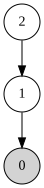

In [11]:
timeserie = load_data("continuous")

test_hgf = (
    Network()
    .add_nodes(precision=1e4)
    .add_nodes(precision=1e4, mean=timeserie[0], tonic_volatility=-13.0, 
               value_children=0)
    # .add_nodes(precision=1e1, tonic_volatility=-14.0, volatility_children=0)
    .add_nodes(precision=1e4, mean=timeserie[0], tonic_volatility=-13.0, 
               value_children=1)
    # .add_nodes(precision=1e1, tonic_volatility=-2.0, volatility_children=1)
    # .add_nodes(precision=1e4, mean=timeserie[0], tonic_volatility=-13.0, 
    #          value_children=1)
    # .add_nodes(precision=1e1, tonic_volatility=-2.0, volatility_children=3)
).create_belief_propagation_fn()

attributes, edges, update_sequence = (
    test_hgf.get_network()
)

test_hgf.plot_network()

<function matplotlib.pyplot.show(close=None, block=None)>

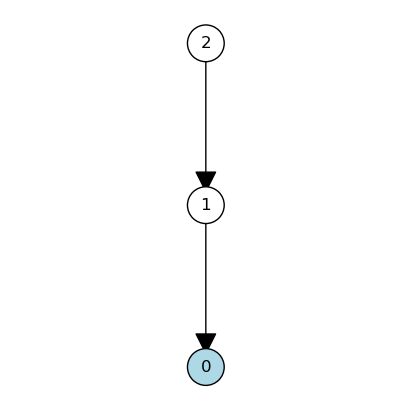

In [12]:
fig = plot_network_x(network=test_hgf)
plt.show

Run functions, plot trajectories and changes

In [13]:
# # Initialize storage lists for trajectories
# trajectories = {
#     'time': [],
#     'node_idx': [],
#     'expected_mean': [],
#     'precision': [],
#     'surprise': [],
#     'input': []
# }

# # Record starting number of nodes
# start_node_count = (len(edges) - 1)

# # Initialize data storage parameters
# snapshot_interval = int((len(input_data))/12) # Adjust for number of snapshots in plots
# snapshot_counter = 0
# snapshot_list = []
# time_step = 0

# # for each observation
# for value in input_data:
#     # interleave observations and masks
#     data = (value, 1.0, 1.0)
#     # update the probabilistic network
#     attributes, _ = beliefs_propagation(
#         attributes=attributes,
#         inputs=data,
#         update_sequence=update_sequence,
#         edges=edges,
#         input_idxs=test_hgf.input_idxs
#     )
    
#     #Create list with node-indexes to be updated
#     index_vec = []
#     node_nr = 0
#     for node in edges:
#         index_vec.append(node_nr)
#         node_nr = node_nr+1
#     nr_removed = 0
        
#     #Update Attributes and Edges
#     for idx in index_vec:
#         edges_dupl = edges
#         attributes, edges = update_structure(attributes=attributes, 
#                                              edges=edges, 
#                                              index=(idx-nr_removed), 
#                                              min_nodes = start_node_count
#         )

#         # If node was removed, +1 to nr_removed
#         if len(edges_dupl) > len(edges):
#             nr_removed = nr_removed+1
        
#         # Store trajectory data 
#         trajectories['time'].append(time_step)
#         trajectories['node_idx'].append((idx-nr_removed))
#         trajectories['expected_mean'].append(attributes[(idx-nr_removed)]['expected_mean'])
#         trajectories['precision'].append(attributes[(idx-nr_removed)]['precision'])
#         surprise_val = gaussian_surprise(x=attributes[(idx-nr_removed)]['mean'], 
#                                      expected_mean=attributes[(idx-nr_removed)]['expected_mean'], 
#                                      expected_precision=attributes[(idx-nr_removed)]['expected_precision'])
#         trajectories['surprise'].append(surprise_val)
#         trajectories['input'].append(value)
    
#     #If snapshot-counter reached interval, store Attributes, Edges
#     if snapshot_counter == snapshot_interval:
#         snap_tuple = (attributes, edges)
#         snapshot_list.append(snap_tuple)
#         snapshot_counter = 0
   
#     snapshot_counter = snapshot_counter + 1
#     time_step = time_step + 1

# # Convert collected data to DataFrame
# trajectory_df = pd.DataFrame(trajectories)

In [14]:
# Initialize storage lists for trajectories
trajectories = {
    'time': [],
    'node_idx': [],
    'expected_mean': [],
    'precision': [],
    'surprise': [],
    'input': []
}

# Record starting number of nodes
start_node_count = (len(edges) - 1)

# Initialize data storage parameters
snapshot_interval = int((len(input_data))/12) # Adjust for number of snapshots in plots
snapshot_counter = 0
snapshot_list = []
time_step = 0

# for each observation
for value in input_data:
    # interleave observations and masks
    data = (value, 1.0, 1.0)
    # update the probabilistic network
    attributes, _ = beliefs_propagation(
        attributes=attributes,
        inputs=data,
        update_sequence=update_sequence,
        edges=edges,
        input_idxs=test_hgf.input_idxs
    )
    
    #Create list with node-indexes to be updated
    index_vec = []
    node_nr = 0
    for node in edges:
        index_vec.append(node_nr)
        node_nr = node_nr+1
    nr_removed = 0
        
    #Update Attributes and Edges
    for idx in index_vec:
        edges_dupl = edges
        attributes, edges = update_structure(attributes=attributes, 
                                             edges=edges, 
                                             index=(idx-nr_removed), 
                                             min_nodes = start_node_count
        )

        # If node was removed, +1 to nr_removed
        if len(edges_dupl) > len(edges):
            nr_removed = nr_removed+1
    
    # Create new list for data-storage
    index_vec_2 = []
    node_nr_2 = 0
    for node in edges:
        index_vec_2.append(node_nr_2)
        node_nr_2 = node_nr_2 + 1
    
    # print(index_vec_2)

    for idx in index_vec_2:

        # Store trajectory data 
        trajectories['time'].append(time_step)
        trajectories['node_idx'].append((idx))
        trajectories['expected_mean'].append(attributes[(idx)]['expected_mean'])
        trajectories['precision'].append(attributes[(idx)]['precision'])
        surprise_val = gaussian_surprise(x=attributes[(idx)]['mean'], 
                                     expected_mean=attributes[(idx)]['expected_mean'], 
                                     expected_precision=attributes[(idx)]['expected_precision'])
        trajectories['surprise'].append(surprise_val)
        trajectories['input'].append(value)
    
    #If snapshot-counter reached interval, store Attributes, Edges
    if snapshot_counter == snapshot_interval:
        snap_tuple = (attributes, edges)
        snapshot_list.append(snap_tuple)
        snapshot_counter = 0
   
    snapshot_counter = snapshot_counter + 1
    time_step = time_step + 1

# Convert collected data to DataFrame
trajectory_df = pd.DataFrame(trajectories)

new node added
new node added
new node added
node removed
node removed
node removed
new node added
new node added
node removed
node removed
new node added
new node added
new node added
node removed
node removed
node removed
new node added
new node added
new node added
node removed
node removed
node removed
new node added
new node added
new node added
node removed
node removed
node removed
new node added
new node added
new node added
node removed
node removed
node removed
new node added
new node added
new node added
node removed
node removed
node removed
new node added
new node added
node removed
node removed
new node added
new node added
node removed
node removed
new node added
node removed
new node added
new node added
node removed
node removed
new node added
new node added
node removed
node removed
new node added
new node added
node removed
node removed
new node added
new node added
node removed
node removed
new node added
node removed
new node added
node removed
new node added
node 

In [21]:
# trajectory_df.to_csv('trajectorie_df_check.csv', index=False)
# trajectory_df

IndexError: tuple index out of range

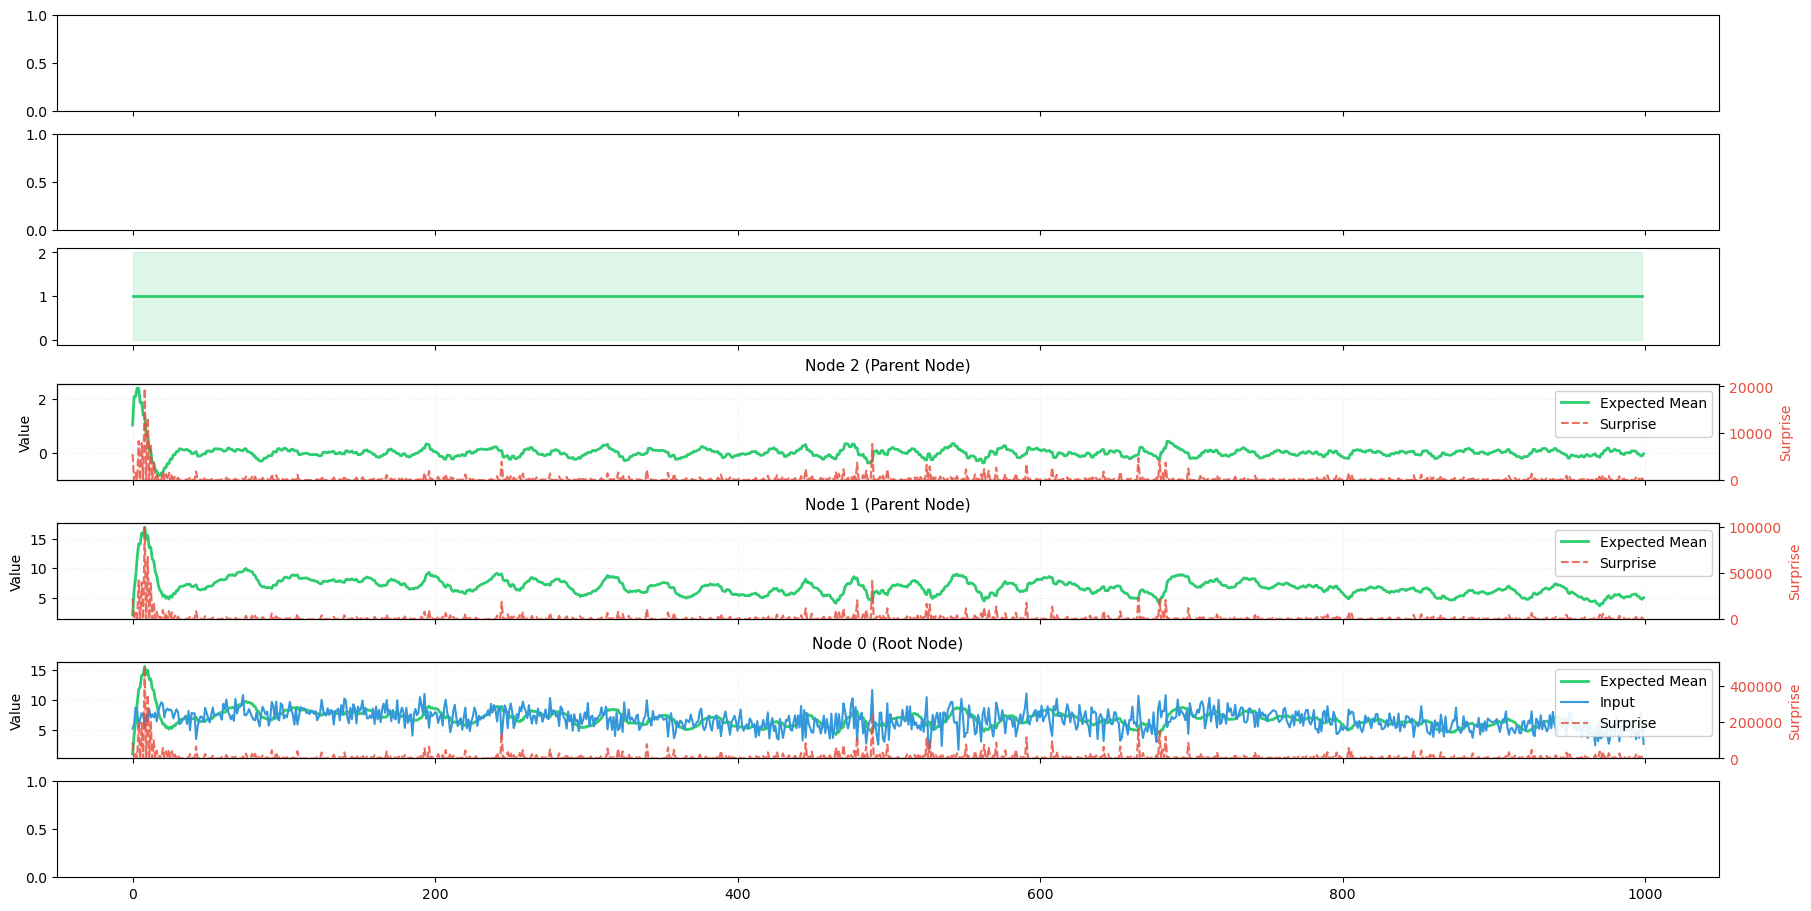

In [16]:
plot_collected_trajectories(
    df=trajectory_df,
    edges=edges, 
    show_surprise=True,
    show_ci=True
)
plt.show()

Plot attempts

C:\Users\hesse\AppData\Local\Temp\ipykernel_25624\4053503888.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


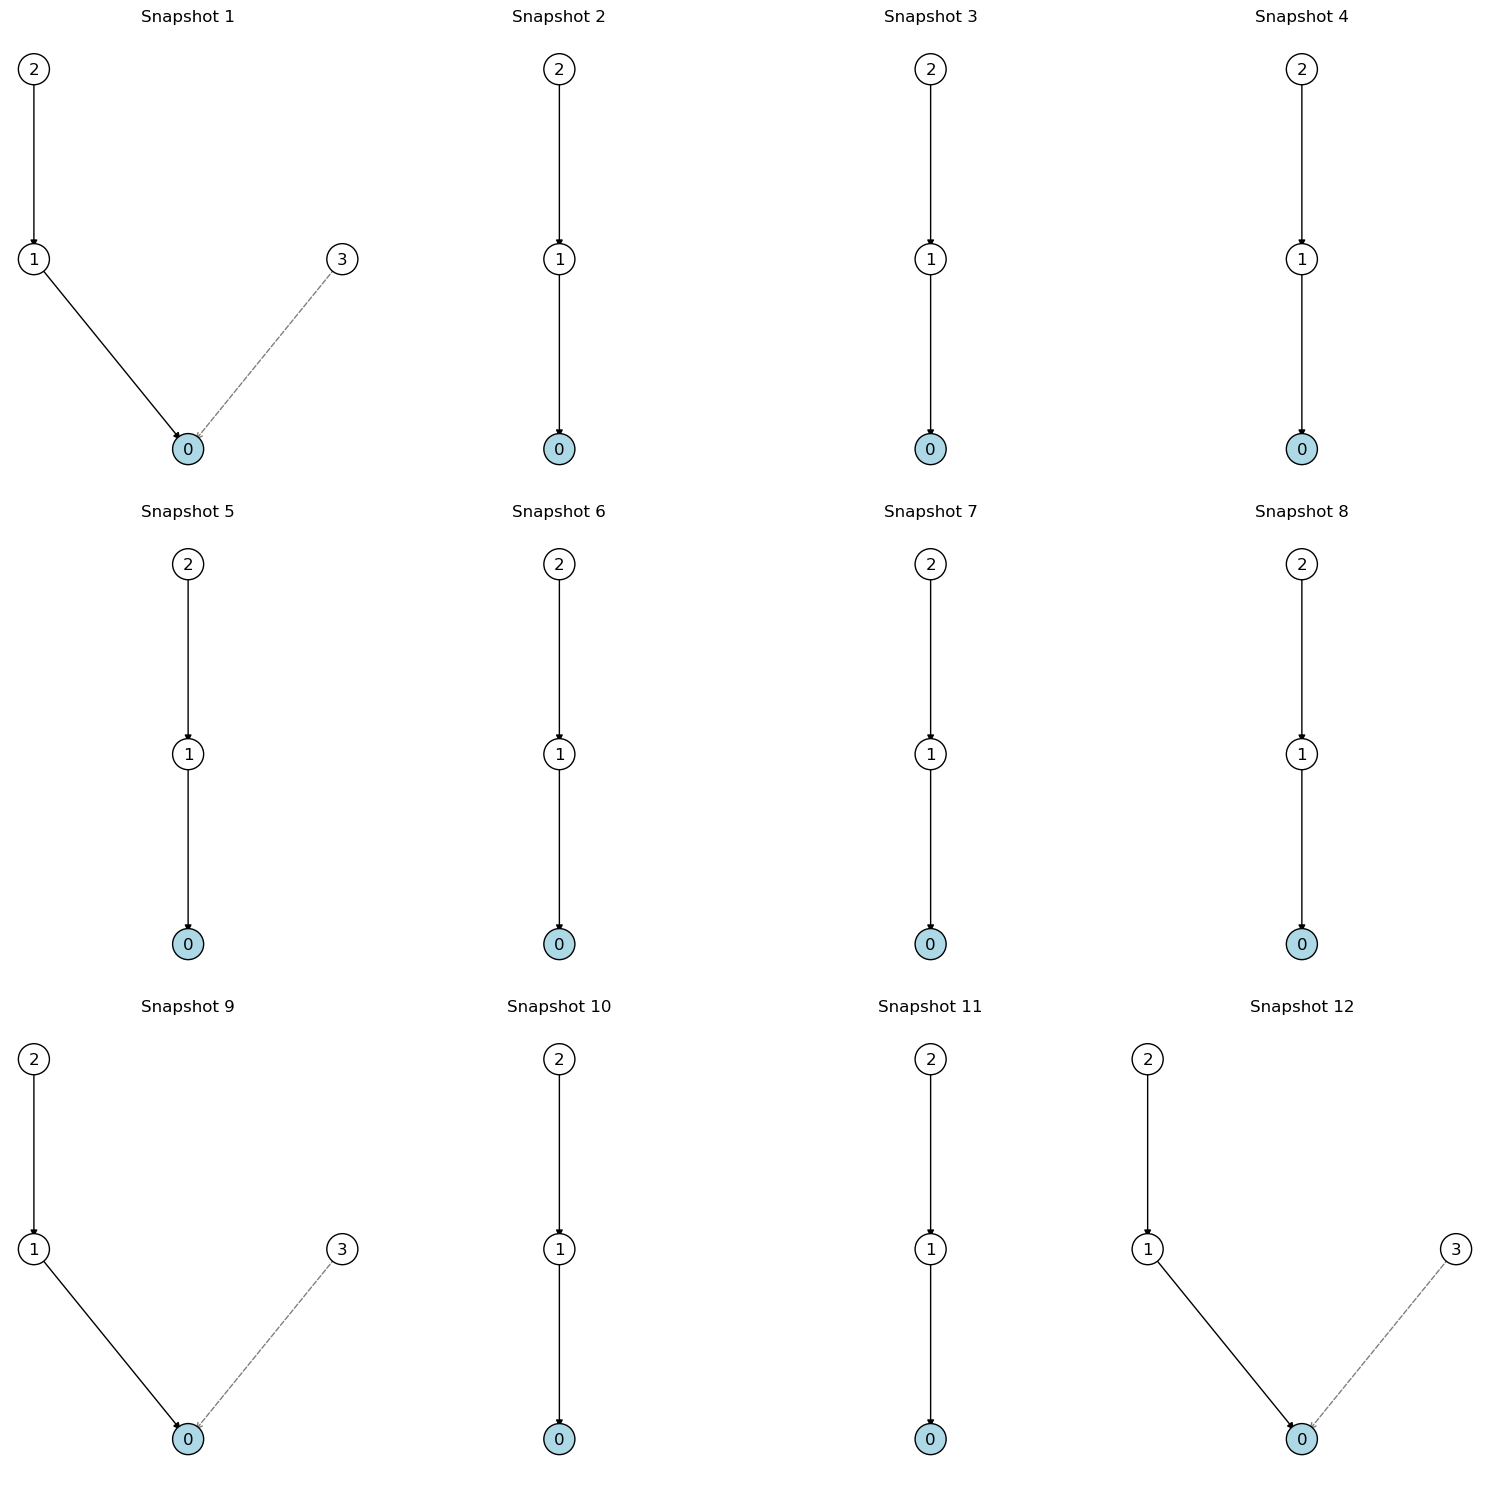

In [17]:
fig = plot_hgf_evolution(test_hgf, snapshot_list, n_cols=4, figsize=(15, 15))

# Display the plot
plt.show()

# Optionally save the figure
# fig.savefig('hgf_evolution.png', dpi=300, bbox_inches='tight')

IndexError: tuple index out of range

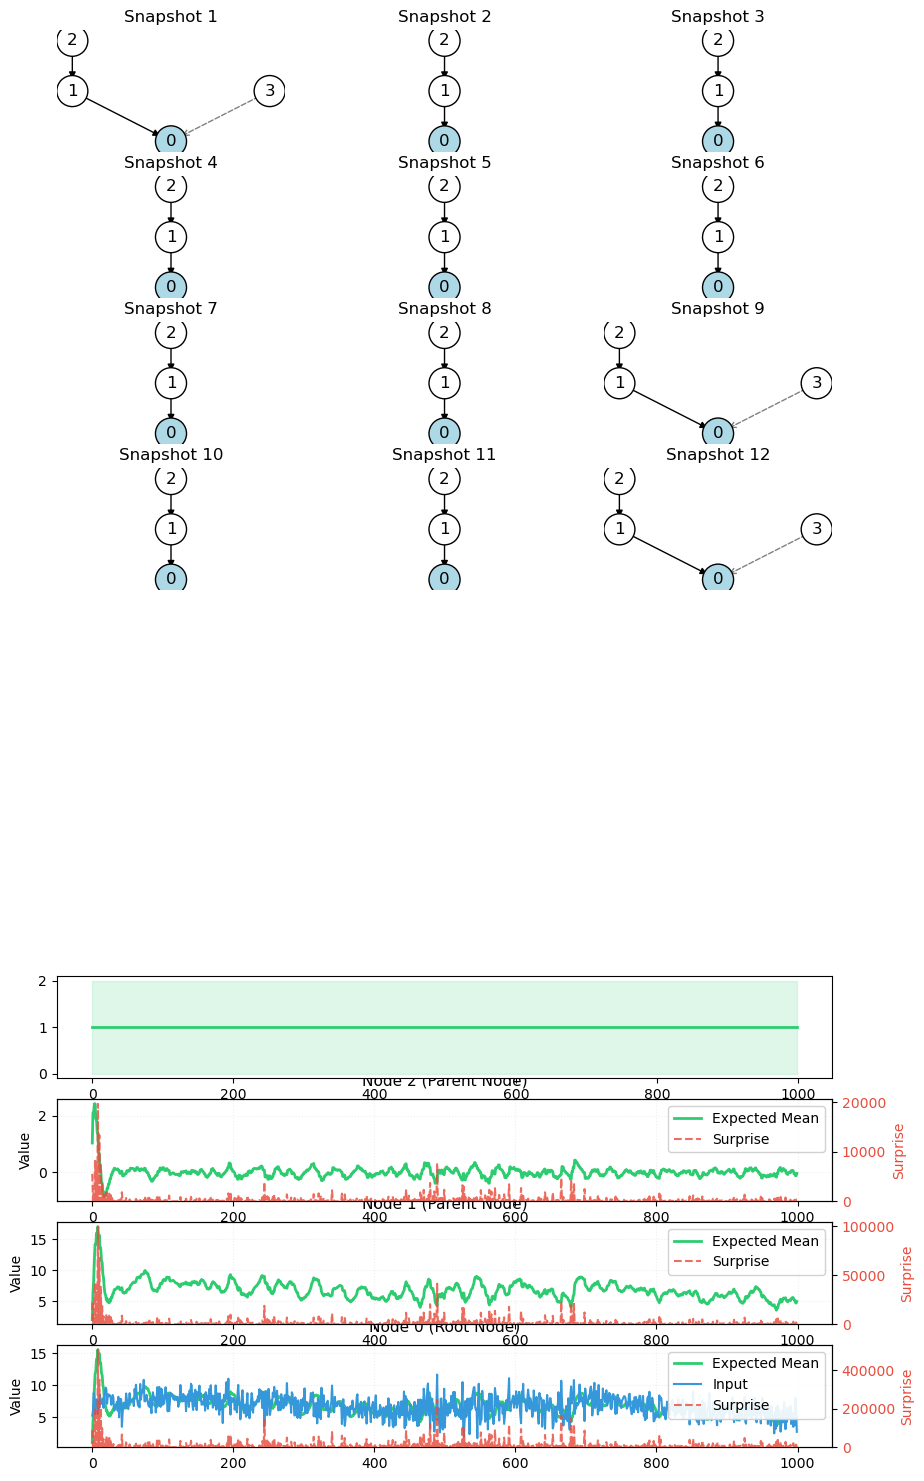

In [19]:
# And now you can also create a combined visualization
combined_fig = plot_combined_hgf_analysis(
    hgf_model=test_hgf,
    snapshot_list=snapshot_list,
    trajectory_df=trajectory_df,
    edges=edges, 
    n_cols=3,  # Adjust for evolution plot layout
    show_surprise=True,
    show_ci=True,
    figsize=(10, 20)  # Adjust overall figure size as needed
)